In [1]:
import pandas as pd
import numpy as np
import scipy.io
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


In [2]:

# Assuming y_train, y_val, y_test are the labels for the training, validation, and test sets


mat = scipy.io.loadmat('train.mat')
X=mat['X']
y=mat['y']


In [3]:
#train test split
X_new=X.transpose(3,0,1,2)
print(X_new.shape)

X_normalized=X_new
y = y.reshape(-1)

# Perform train-test-validation split
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.3)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.14)
y_train[y_train == 10] = 0
y_test[y_test == 10] = 0
y_val[y_val == 10] = 0


(73257, 32, 32, 3)


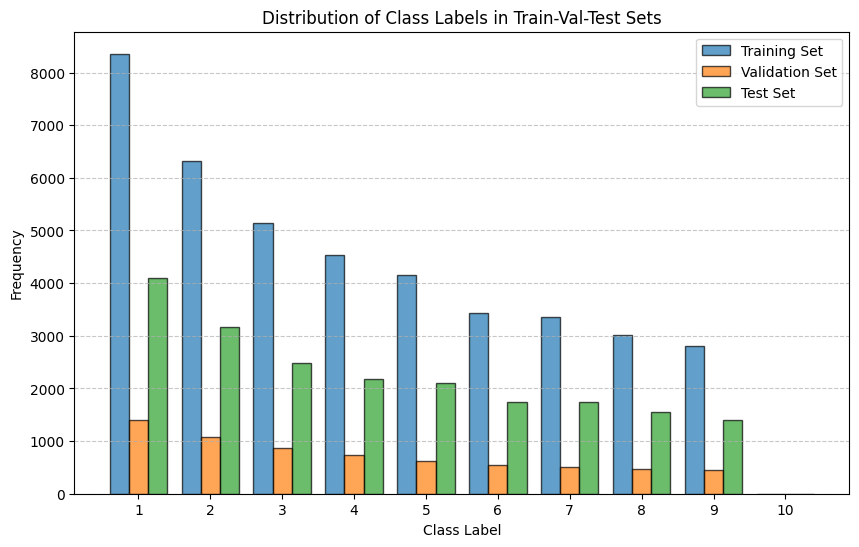

In [4]:
#distribution of classes
plt.figure(figsize=(10, 6))
plt.hist([y_train, y_val, y_test], bins=np.arange(np.min(y), np.max(y) + 1.5) - 0.5, edgecolor='black', alpha=0.7, rwidth=0.8)
plt.title('Distribution of Class Labels in Train-Val-Test Sets')
plt.xlabel('Class Label')
plt.ylabel('Frequency')
plt.xticks(np.arange(np.min(y), np.max(y) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(['Training Set', 'Validation Set', 'Test Set'])
plt.show()


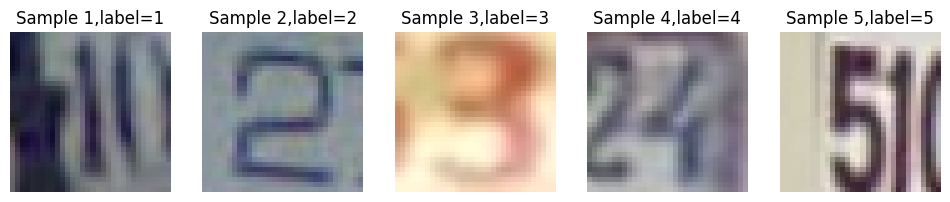

In [15]:

random_indices = []
for i in range(1,6):
    f=(np.where(y_train == i))[0][0]
    random_indices.append(f)  

# Plot the selected images
plt.figure(figsize=(12, 4))
for i, idx in enumerate(random_indices, 1):
    plt.subplot(1, 5, i)
    j=X_train[idx]
    plt.imshow(j)
    plt.title(f"Sample {i},label={y_train[idx]}")
    plt.axis('off')

plt.show()

In [4]:

X_train_flat = X_train.reshape(X_train.shape[0], -1)
# random_indices = np.random.choice(X_flat.shape[0], 1, replace=False)
# print(X_flat[random_indices])
# plt.figure(figsize=(12, 4))
# for i, idx in enumerate(random_indices, 1):
#     plt.imshow(X_flat[idx].reshape(32, 32, 3))
# plt.show()
X_test_flat=X_test.reshape(X_test.shape[0], -1)
X_val_flat=X_val.reshape(X_val.shape[0], -1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)


In [7]:
mlp=MLPClassifier(hidden_layer_sizes=(300,300),batch_size=150,max_iter=15,verbose=3)
mlp.fit(X_train_scaled,y_train)


Iteration 1, loss = 1.54114149
Iteration 2, loss = 0.94911763
Iteration 3, loss = 0.81350559
Iteration 4, loss = 0.71092218
Iteration 5, loss = 0.65936194
Iteration 6, loss = 0.60406023
Iteration 7, loss = 0.56648517
Iteration 8, loss = 0.52507054
Iteration 9, loss = 0.50421299
Iteration 10, loss = 0.47578053
Iteration 11, loss = 0.44908741
Iteration 12, loss = 0.42142722
Iteration 13, loss = 0.41711703
Iteration 14, loss = 0.39604855
Iteration 15, loss = 0.38913327


/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=150, hidden_layer_sizes=(300, 300), max_iter=15,
              verbose=3)

In [8]:

y_train_pred=mlp.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy}")


y_test_pred=mlp.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")


y_val_pred=mlp.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Val Accuracy: {val_accuracy}")


Train Accuracy: 0.8860064854078323
Test Accuracy: 0.7985257985257985
Val Accuracy: 0.803899721448468


In [9]:
from joblib import parallel_backend
param_grid = {
    'hidden_layer_sizes': [(300, 300), (500, 500),(600,600)],
    # 'activation': ['relu','sigmoid','tanh','linear'],
    'batch_size': [50,100,150],
    'max_iter': [10, 15, 17]
}
mlp_classififer=MLPClassifier()
grid_search = GridSearchCV(mlp_classififer, param_grid, cv=3, scoring='accuracy',n_jobs=10,verbose=4)

In [10]:
grid_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/opt/conda/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_mult

[CV 1/3] END batch_size=50, hidden_layer_sizes=(300, 300), max_iter=17;, score=0.783 total time=33.3min
[CV 3/3] END batch_size=50, hidden_layer_sizes=(500, 500), max_iter=17;, score=0.777 total time=52.5min
[CV 2/3] END batch_size=100, hidden_layer_sizes=(300, 300), max_iter=10;, score=0.764 total time= 9.8min
[CV 3/3] END batch_size=100, hidden_layer_sizes=(300, 300), max_iter=15;, score=0.790 total time=14.5min
[CV 2/3] END batch_size=100, hidden_layer_sizes=(500, 500), max_iter=10;, score=0.762 total time=18.6min
[CV 3/3] END batch_size=100, hidden_layer_sizes=(500, 500), max_iter=17;, score=0.787 total time=31.3min
[CV 2/3] END batch_size=150, hidden_layer_sizes=(300, 300), max_iter=10;, score=0.787 total time= 8.3min
[CV 3/3] END batch_size=150, hidden_layer_sizes=(300, 300), max_iter=15;, score=0.791 total time=11.8min
[CV 2/3] END batch_size=150, hidden_layer_sizes=(500, 500), max_iter=10;, score=0.780 total time=14.7min
[CV 3/3] END batch_size=150, hidden_layer_sizes=(600, 600

/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 2/3] END batch_size=50, hidden_layer_sizes=(300, 300), max_iter=17;, score=0.776 total time=33.6min
[CV 1/3] END batch_size=50, hidden_layer_sizes=(600, 600), max_iter=10;, score=0.757 total time=37.7min
[CV 3/3] END batch_size=50, hidden_layer_sizes=(600, 600), max_iter=15;, score=0.767 total time=56.1min
[CV 2/3] END batch_size=100, hidden_layer_sizes=(500, 500), max_iter=17;, score=0.779 total time=28.8min
[CV 1/3] END batch_size=150, hidden_layer_sizes=(300, 300), max_iter=10;, score=0.785 total time= 8.1min
[CV 2/3] END batch_size=150, hidden_layer_sizes=(300, 300), max_iter=15;, score=0.782 total time=12.0min
[CV 1/3] END batch_size=150, hidden_layer_sizes=(500, 500), max_iter=10;, score=0.785 total time=14.0min
[CV 3/3] END batch_size=150, hidden_layer_sizes=(500, 500), max_iter=17;, score=0.790 total time=22.7min
[CV 1/3] END batch_size=50, hidden_layer_sizes=(500, 500), max_iter=10;, score=0.767 total time=33.3min
[CV 2/3] END batch_size=50, hidden_layer_sizes=(600, 600), 

...

[CV 3/3] END batch_size=50, hidden_layer_sizes=(300, 300), max_iter=10;, score=0.774 total time=20.1min
[CV 1/3] END batch_size=50, hidden_layer_sizes=(500, 500), max_iter=15;, score=0.769 total time=45.3min
[CV 2/3] END batch_size=50, hidden_layer_sizes=(600, 600), max_iter=15;, score=0.763 total time=56.6min
[CV 2/3] END batch_size=100, hidden_layer_sizes=(500, 500), max_iter=15;, score=0.790 total time=25.7min
[CV 2/3] END batch_size=100, hidden_layer_sizes=(600, 600), max_iter=15;, score=0.780 total time=33.7min
[CV 3/3] END batch_size=150, hidden_layer_sizes=(500, 500), max_iter=10;, score=0.783 total time=13.9min
[CV 1/3] END batch_size=150, hidden_layer_sizes=(600, 600), max_iter=15;, score=0.786 total time=22.6min


/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (17) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (17) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (17) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 2/3] END batch_size=50, hidden_layer_sizes=(300, 300), max_iter=10;, score=0.764 total time=19.9min
[CV 2/3] END batch_size=50, hidden_layer_sizes=(500, 500), max_iter=10;, score=0.748 total time=31.3min
[CV 3/3] END batch_size=50, hidden_layer_sizes=(600, 600), max_iter=10;, score=0.736 total time=38.3min
[CV 1/3] END batch_size=100, hidden_layer_sizes=(300, 300), max_iter=15;, score=0.774 total time=14.9min
[CV 2/3] END batch_size=100, hidden_layer_sizes=(300, 300), max_iter=17;, score=0.779 total time=17.5min
[CV 1/3] END batch_size=100, hidden_layer_sizes=(500, 500), max_iter=15;, score=0.770 total time=26.1min
[CV 3/3] END batch_size=100, hidden_layer_sizes=(600, 600), max_iter=15;, score=0.773 total time=33.8min
[CV 1/3] END batch_size=150, hidden_layer_sizes=(500, 500), max_iter=15;, score=0.797 total time=20.8min
[CV 2/3] END batch_size=150, hidden_layer_sizes=(600, 600), max_iter=15;, score=0.784 total time=19.2min
[CV 2/3] END batch_size=50, hidden_layer_sizes=(300, 300),

/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=3, estimator=MLPClassifier(), n_jobs=10,
             param_grid={'batch_size': [50, 100, 150],
                         'hidden_layer_sizes': [(300, 300), (500, 500),
                                                (600, 600)],
                         'max_iter': [10, 15, 17]},
             scoring='accuracy', verbose=4)

In [11]:
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

# Evaluate the Model on Training Set using the best parameters
best_model = MLPClassifier(**grid_search.best_params_)
best_model.fit(X_train_scaled, y_train)
y_train_pred = best_model.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy with Best Parameters: {train_accuracy}")

# Evaluate the Model on Test Set using the best parameters
y_test_pred = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy with Best Parameters: {test_accuracy}")

# Evaluate the Model on Validation Set using the best parameters
y_val_pred = best_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy with Best Parameters: {val_accuracy}")


Best Parameters: {'batch_size': 150, 'hidden_layer_sizes': (300, 300), 'max_iter': 15}
Best Accuracy: 0.7908342708922923
[CV 3/3] END batch_size=50, hidden_layer_sizes=(300, 300), max_iter=17;, score=0.785 total time=33.0min
[CV 2/3] END batch_size=50, hidden_layer_sizes=(500, 500), max_iter=17;, score=0.757 total time=52.8min
[CV 3/3] END batch_size=100, hidden_layer_sizes=(300, 300), max_iter=10;, score=0.776 total time=10.2min
[CV 1/3] END batch_size=100, hidden_layer_sizes=(300, 300), max_iter=17;, score=0.788 total time=17.2min
[CV 3/3] END batch_size=100, hidden_layer_sizes=(500, 500), max_iter=10;, score=0.788 total time=18.2min
[CV 1/3] END batch_size=100, hidden_layer_sizes=(600, 600), max_iter=10;, score=0.782 total time=22.7min
[CV 2/3] END batch_size=100, hidden_layer_sizes=(600, 600), max_iter=17;, score=0.761 total time=37.9min
[CV 1/3] END batch_size=150, hidden_layer_sizes=(600, 600), max_iter=10;, score=0.782 total time=17.6min
[CV 2/3] END batch_size=150, hidden_layer

/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


Train Accuracy with Best Parameters: 0.8933535907843715
Test Accuracy with Best Parameters: 0.8017563017563017
Validation Accuracy with Best Parameters: 0.8059888579387187


In [5]:

from sklearn.metrics import log_loss
# activation_functions = ['logistic']
activation_functions = ['logistic', 'relu', 'tanh', 'identity']
# Store training and validation loss for each activation function
training_loss_dict = {}
validation_loss_dict = {}

# Train the model with different activation functions
for activation_func in activation_functions:
    print(f"\nTraining with Activation Function: {activation_func}")
    
    # Build the MLP model
    mlp_classifier = MLPClassifier(
        activation=activation_func,
        hidden_layer_sizes=(300,300),
        batch_size=150,
        # hidden_layer_sizes=grid_search.best_params_['hidden_layer_sizes'],
        # batch_size=grid_search.best_params_['batch_size'],
        warm_start=True,
        max_iter=1
          # This allows incremental learning, continuing training on the existing model
    )
    
    # Initialize lists to store training and validation losses
    training_losses = []
    validation_losses = []
    
    # Train the model in iterations
    for epoch in range(15):
        mlp_classifier.fit(X_train_scaled, y_train)
        
        # Record training loss
        training_loss = mlp_classifier.loss_
        training_losses.append(training_loss)
        
        # Record validation loss
        y_val_pred_proba = mlp_classifier.predict_proba(X_val_scaled)
        validation_losses.append(log_loss(y_val, y_val_pred_proba))
    
    y_train_pred=mlp_classifier.predict(X_train_scaled)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"Train Accuracy: {train_accuracy}")


    y_test_pred=mlp_classifier.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"Test Accuracy: {test_accuracy}")


    y_val_pred=mlp_classifier.predict(X_val_scaled)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    print(f"Val Accuracy: {val_accuracy}")  
    # Store the final training and validation losses for each activation function
    training_loss_dict[activation_func] = training_losses
    validation_loss_dict[activation_func] = validation_losses

# Plot validation loss vs. epochs for each activation function



Training with Activation Function: logistic


c:\Users\gupta\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:679: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Train Accuracy: 0.8502460373251094
Test Accuracy: 0.7922012922012922
Val Accuracy: 0.7933147632311978

Training with Activation Function: relu


c:\Users\gupta\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:679: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Train Accuracy: 0.8886369305426427
Test Accuracy: 0.8007553007553008
Val Accuracy: 0.7923398328690808

Training with Activation Function: tanh


c:\Users\gupta\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:679: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Train Accuracy: 0.7961405020522008
Test Accuracy: 0.7335972335972336
Val Accuracy: 0.7327298050139276

Training with Activation Function: identity


c:\Users\gupta\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:679: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


Train Accuracy: 0.26975668382503004
Test Accuracy: 0.2558012558012558
Val Accuracy: 0.25


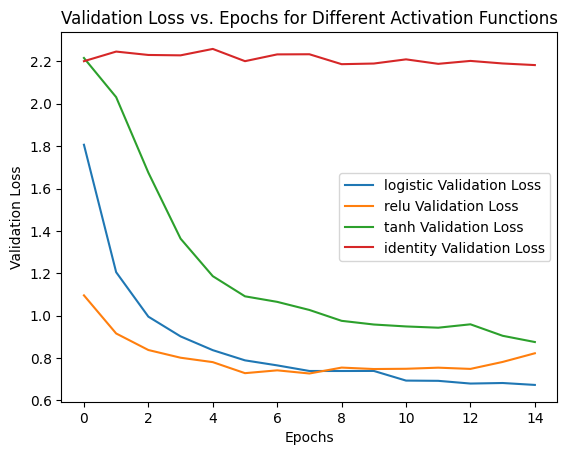

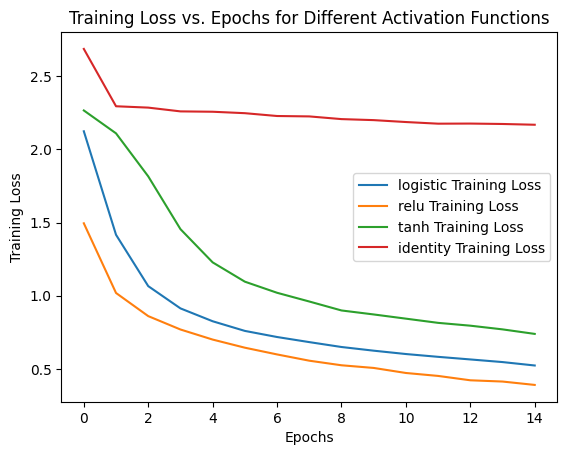

In [6]:
for activation_func in activation_functions:
    plt.plot(validation_loss_dict[activation_func], label=f'{activation_func} Validation Loss')



# Plot settings
plt.title('Validation Loss vs. Epochs for Different Activation Functions')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

for activation_func in activation_functions:
    plt.plot(training_loss_dict[activation_func], label=f'{activation_func} Training Loss')

plt.title('Training Loss vs. Epochs for Different Activation Functions')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.legend()
plt.show()


In [14]:
mlp2=MLPClassifier(**grid_search.best_params_)
mlp2.fit(X_train_scaled,y_train)

/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=150, hidden_layer_sizes=(300, 300), max_iter=15)

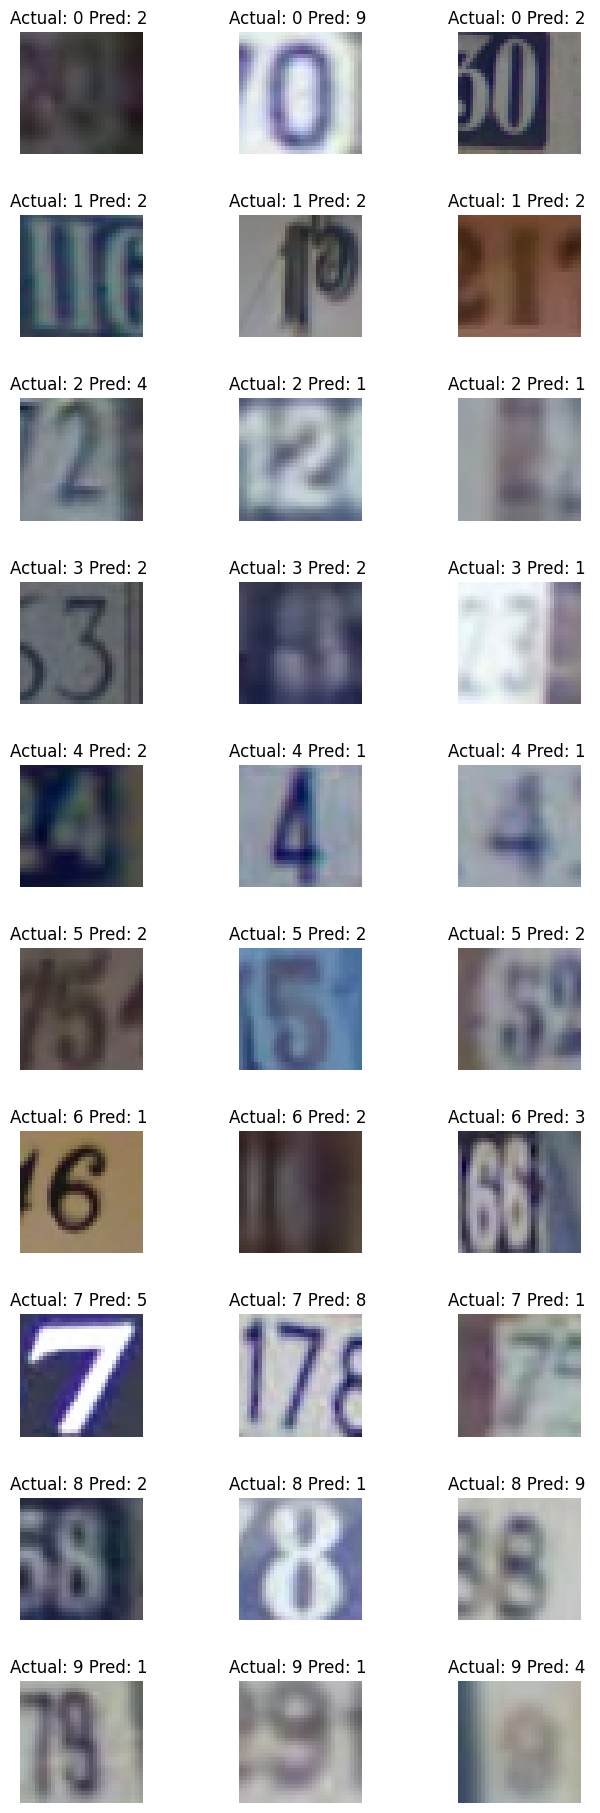

In [15]:
y_pred=mlp2.predict(X_test_scaled)
misclassified_indices = np.where(y_test != y_test_pred)[0]
plt.figure(figsize=(8, 23))
# Visualize 3 misclassified images for each class
for class_label in np.unique(y_test):
    misclassified_for_class = misclassified_indices[y_test[misclassified_indices] == class_label][:3]

    for i, misclassified_index in enumerate(misclassified_for_class):
        plt.subplot(len(np.unique(y_test)), 3, class_label * 3 + i + 1)
        plt.imshow(X_test[misclassified_index].reshape(32, 32, 3))
        plt.title(f'Actual: {y_test[misclassified_index]} Pred: {y_test_pred[misclassified_index]} ')
        plt.axis('off')
plt.subplots_adjust(wspace=0.2, hspace=0.5) 
plt.show()